# 12 · Experiments and reports

Two tools organise the work around the models:

* `NowcastExperiment` fits several specifications on the **same** data, tabulates
  their nowcasts, runs a pseudo real-time backtest for each and ranks them — the
  bookkeeping of a model-selection study (modelled on `panelbox.experiment`);
* `NowcastReport` writes a self-contained **HTML report** for one model: headline
  nowcast with bands, path, news and nowcast tracker, data flow (ragged edge),
  backtest accuracy and DFM diagnostics (innovation I9).

In [1]:
import sys
from pathlib import Path

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
sys.path.insert(0, str(HERE.parent))

from utils import OUTPUTS_DIR, brazil_panel, display, md, setup, show

import nowcastbox as nb

setup(blas_threads=1)

## 1. Four specifications

On the compact Brazilian panel (GDP + 21 indicators):

| name | model |
|---|---|
| `two_step` | two-step DFM (Doz, Giannone & Reichlin, 2011), r = 2, VAR(1), bridge on quarterly factors |
| `em_global` | EM DFM, one global factor |
| `em_blocks` | EM DFM, global + real/nominal/financial/soft blocks (NY Fed style) |
| `em_robust` | `em_blocks` with Student-t idiosyncratic errors (I3) |

In [2]:
ds, panel = brazil_panel(start="2005-01")
exp = nb.NowcastExperiment(
    panel,
    "pib",
    models={
        "two_step": nb.TwoStepDFM(n_factors=2, factor_lags=1),
        "em_global": nb.MixedFreqDFM(n_factors=1, max_iter=200),
        "em_blocks": nb.MixedFreqDFM(n_factors=1, blocks="data", max_iter=200),
        "em_robust": nb.MixedFreqDFM(
            n_factors=1, blocks="data", idiosyncratic="student_t", max_iter=200
        ),
    },
)
results = exp.fit_all()
print(exp.summary())

NowcastExperiment: target pib, 4 model(s), 4 fitted
          nowcast_period  nowcast  loglikelihood  rmse_in_sample  r2_in_sample  fit_seconds
model                                                                                      
two_step          2026Q3   0.0008     -6781.8456          0.0068        0.7011       0.1661
em_global         2026Q3  -0.0004     -6478.2336          0.0077        0.6212       0.2181
em_blocks         2026Q3  -0.0007     -6207.1119          0.0064        0.7326       0.4809
em_robust         2026Q3  -0.0008     -6394.8541          0.0068        0.6981       0.4985


In [3]:
display(exp.compare("2026Q3"))

,model_name,nowcast_period,nowcast,std,lower_90,upper_90,...,converged,n_in_sample,rmse_in_sample,mae_in_sample,r2_in_sample,fit_seconds
model,,,,,,,,,,,,,
two_step,TwoStepDFM,2026Q3,0.0008,0.0088,NaN,NaN,...,None,85.0,0.0068,0.0051,0.7011,0.1661
em_global,MixedFreqDFM,2026Q3,-0.0004,0.0086,-0.0146,0.0137,...,True,85.0,0.0077,0.0054,0.6212,0.2181
em_blocks,MixedFreqDFM,2026Q3,-0.0007,0.0084,-0.0145,0.0131,...,True,85.0,0.0064,0.0048,0.7326,0.4809
em_robust,MixedFreqDFM,2026Q3,-0.0008,0.0083,-0.0145,0.0129,...,True,85.0,0.0068,0.0050,0.6981,0.4985


,observed,two_step,em_global,em_blocks,em_robust
period,,,,,
2025Q3,0.0011,0.0043,0.0057,0.0049,5.6450e-03
2025Q4,0.0025,0.0003,0.0012,0.0005,-7.7782e-05
2026Q1,0.0107,0.0094,0.0098,0.0098,9.9496e-03
2026Q2,0.0048,0.0044,0.0049,0.0046,4.4953e-03
2026Q3,NaN,0.0008,-0.0004,-0.0007,-7.6589e-04
2026Q4,NaN,0.0057,NaN,NaN,NaN


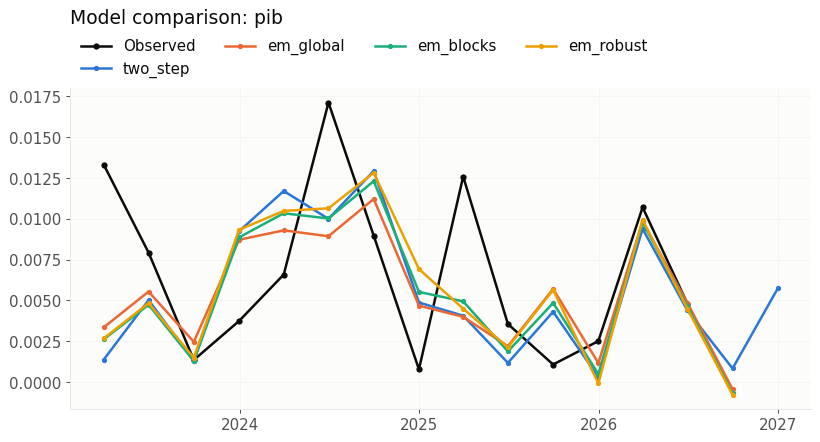

In [4]:
display(exp.nowcast_table().tail(6))
fig = exp.plot("nowcasts", backend="matplotlib", n_periods=16)
show(fig, "12_nowcasts")

The four specifications agree on the broad picture — weak growth in 2026Q3 — but
differ by a few tenths of a percentage point, the same order as the revision a
nowcast typically undergoes within a quarter. Which one to trust is an empirical
question.

## 2. Backtesting every specification

`run_backtest()` without a custom hook runs a `PseudoRealTimeBacktest` of each model
with the given options (here: monthly vintages in 2022–2025 with the actual release
calendar, parameters re-estimated quarterly).

,two_step,em_global,em_blocks,em_robust
months_to_end,,,,
-2,0.575,0.573,0.562,0.562
-1,0.778,0.716,0.711,0.705
0,0.625,0.608,0.557,0.544
1,0.718,0.695,0.612,0.618
2,0.784,0.644,0.530,0.490
3,0.576,0.572,0.497,0.484
4,0.523,0.520,0.497,0.489
5,0.522,0.522,0.504,0.496


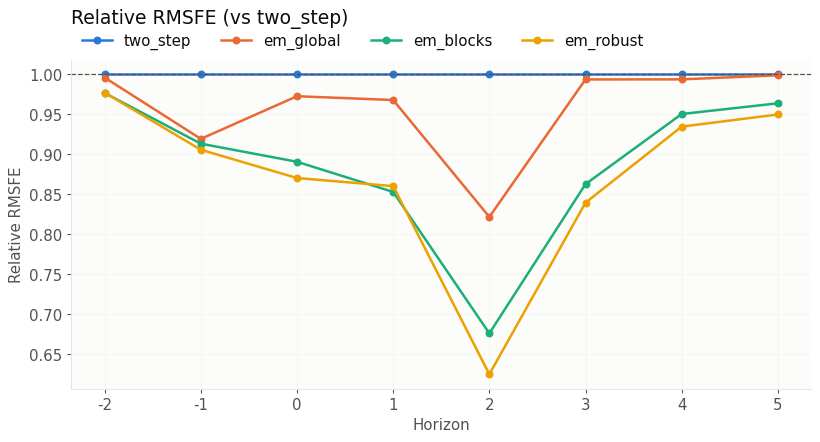

In [5]:
backtests = exp.run_backtest(
    calendar=nb.load_brazil_calendar(),
    start="2022-01-15",
    end="2025-12-15",
    step="M",
    refit_every=3,
    n_jobs=4,
)
rmsfe = exp.rmsfe_table()
display((100 * rmsfe).round(3))
fig = exp.plot("rmsfe", backend="matplotlib", relative_to="two_step")
show(fig, "12_rmsfe")

In [6]:
best = rmsfe.loc[[0, -1]].mean().idxmin()
md(
    f"Averaging the nowcast (`months_to_end = 0`) and backcast (`−1`) horizons, the most "
    f"accurate specification over 2022–2025 is **`{best}`**. With 16 target quarters this "
    "is indicative only: notebook 08 shows how to test the differences "
    "(Diebold-Mariano, Model Confidence Set)."
)

Averaging the nowcast (`months_to_end = 0`) and backcast (`−1`) horizons, the most accurate specification over 2022–2025 is **`em_robust`**. With 16 target quarters this is indicative only: notebook 08 shows how to test the differences (Diebold-Mariano, Model Confidence Set).

## 3. Diagnostics of the chosen model (I9)

`res.diagnostics()` checks the convergence of the EM, the stability of the loadings
(Breitung & Eickmeier, 2011, sup-LM tests over break dates), the contribution of each
factor, residual autocorrelation and normality, and data-quality issues.

In [7]:
res = exp.get_results("em_blocks")
diag = res.diagnostics()
print(diag.summary())

Diagnostics: MixedFreqDFM (target: pib)
Data quality
  Series                    22 (panel ends 2026-09)
  Missing share (slots)     0.016
  Ragged edge (periods)     max 4, mean 1.50
  Outliers                  2 in 2 series
  Near-zero loadings        -
  ! pim_transformacao       outliers(1)
  ! pim_bens_capital        outliers(1)
------------------------------------------------------------------------------
EM convergence
  Converged                 True (tol=0.0001)
  Iterations                8
  Log-likelihood            -6337.6938 -> -6207.1119
  Last relative change      9.64e-05
  Non-monotone steps        0
------------------------------------------------------------------------------
Loading stability (Breitung & Eickmeier, 2011)
  Test: unknown break date (sup over [0.15, 0.85]); statistic for decisions: LM; alpha=0.05; correction=holm
           n_tests  n_reject  share_reject  expected_reject  binomial_pvalue  n_reject_adjusted
statistic                                  

In [8]:
display(diag.series_overview().head(10))

,na_share,ragged_edge,n_outliers,near_zero_loading,r2,break_pvalue_adj,unstable_loadings,lb_pvalue,jb_pvalue,flags
series,,,,,,,,,,
pib,0.0230,1,0,False,0.7589,1.0000,False,6.3794e-01,1.7202e-06,
ibc_br,0.0077,2,0,False,0.2081,0.0660,False,2.7107e-01,2.4478e-34,
pim_geral,0.0077,2,0,False,0.9346,0.0011,True,8.5198e-02,0.0000e+00,unstable_loadings
pim_transformacao,0.0077,2,1,False,0.9730,0.7112,False,2.6175e-01,7.2400e-40,outliers(1)
pim_bens_capital,0.0077,2,1,False,0.2612,1.0000,False,3.9921e-01,3.0592e-24,outliers(1)
pim_bens_consumo_duraveis,0.0077,2,0,False,0.5576,1.0000,False,2.6016e-03,1.0828e-02,autocorrelated_residuals
pmc_varejo,0.0077,2,0,False,0.0825,1.0000,False,5.2118e-03,4.5566e-12,autocorrelated_residuals
pmc_ampliado,0.0077,2,0,False,0.1565,0.3536,False,6.9227e-02,2.0893e-13,
ipea_fbcf,0.0154,4,0,False,0.2098,0.5062,False,1.0738e-04,2.3903e-25,autocorrelated_residuals


**Reading the diagnostics.** The EM converged and the data-quality checks are clean,
but the loadings of about half the indicators are unstable over 2005–2026 — not
surprising for an economy that went through the 2014–2016 recession, a change of the
industrial survey's base year and the pandemic. Many idiosyncratic residuals are
autocorrelated and fat-tailed even with AR(1) idiosyncratic terms (in part because
2020 is in the sample). These flags argue for the robust options of notebook 10 and
for re-checking the specification periodically; they do not invalidate the nowcast,
whose out-of-sample accuracy is the ultimate test (section 2).

## 4. The HTML report

The report bundles everything a monetary-policy briefing needs. We add the news of the
last month and the nowcast tracker of the quarter (notebook 07), the predictive
density (notebook 13) and the backtest of section 2.

In [9]:
calendar = nb.load_brazil_calendar()
old = nb.pseudo_real_time(panel, calendar=calendar, vintage="2026-09-01")
news = res.news(old, panel, target_period="2026Q3")
tracker = res.nowcast_tracker(panel, calendar, "2026Q3", "2026-07-01", "2026-10-01")
OUTPUTS_DIR.mkdir(exist_ok=True)
path = OUTPUTS_DIR / "12_report_em_blocks.html"
html = exp.report(
    "em_blocks",
    path,
    title="Brazilian GDP nowcast - EM DFM with blocks",
    news=news,
    tracker=tracker,
    quantiles=res.distribution(),
    diagnostics=diag,
    author="nowcastbox example 12",
    plotlyjs="cdn",  # smaller file; "inline" makes it work offline
)
sections = [
    s for s in ("headline", "path", "news", "data_flow", "diagnostics") if f'id="{s}"' in html
]
md(
    f"Report written to `{path.relative_to(OUTPUTS_DIR.parent)}` "
    f"({len(html) / 1024:.0f} KiB) with sections: {', '.join(sections)} (the estimation "
    "and diagnostics card also holds the factor charts and the backtest RMSFE). "
    "Open it in a browser — the charts are interactive Plotly figures."
)

Report written to `outputs/12_report_em_blocks.html` (211 KiB) with sections: headline, path, news, data_flow, diagnostics (the estimation and diagnostics card also holds the factor charts and the backtest RMSFE). Open it in a browser — the charts are interactive Plotly figures.

`NowcastReport` can also be used directly with any results object
(`nb.NowcastReport(res, news=..., theme="academic").to_html(path)`); `theme` accepts
the themes of `nb.visualization.list_themes()` and `template_dir` a custom Jinja2
template.

### References

* Breitung, J. & Eickmeier, S. (2011). Testing for structural breaks in dynamic factor
  models. *Journal of Econometrics*, 163(1), 71–84.
* Doz, C., Giannone, D. & Reichlin, L. (2011). *Journal of Econometrics*, 164(1),
  188–205.
* Bańbura, M. & Modugno, M. (2014). *Journal of Applied Econometrics*, 29(1), 133–160.